In [11]:

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

def load_row_data():
    
    start = time.time()

    FOLDER_PATH = r"D:\matplotlib_project\Data"

    for file in os.listdir(FOLDER_PATH):
        if not file.lower().endswith(".csv"):
            continue

        file_path = os.path.join(FOLDER_PATH, file)
        df = pd.read_csv(file_path)

        end = time.time()
        total_time = end - start

        print(f"Data Loaded: {file}")
        print(f"Total Time Taken: {total_time:.2f} seconds")

        return df

    
if __name__ == "__main__":
    df = load_row_data()
    
    
    

Data Loaded: IPL.csv
Total Time Taken: 0.01 seconds


In [12]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


### Get basic ingo about data

In [13]:
#df.shape
#OR
print(f"Your data rows are {df.shape[0]} and columns are {df.shape[1]}")

Your data rows are 74 and columns are 20


### Get shape of data like rows and columns....

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

### Checks how many columns have NULLs 

In [15]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [16]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

## `#1 .` Checks which team won the most matches...........

In [17]:
match_wins = df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

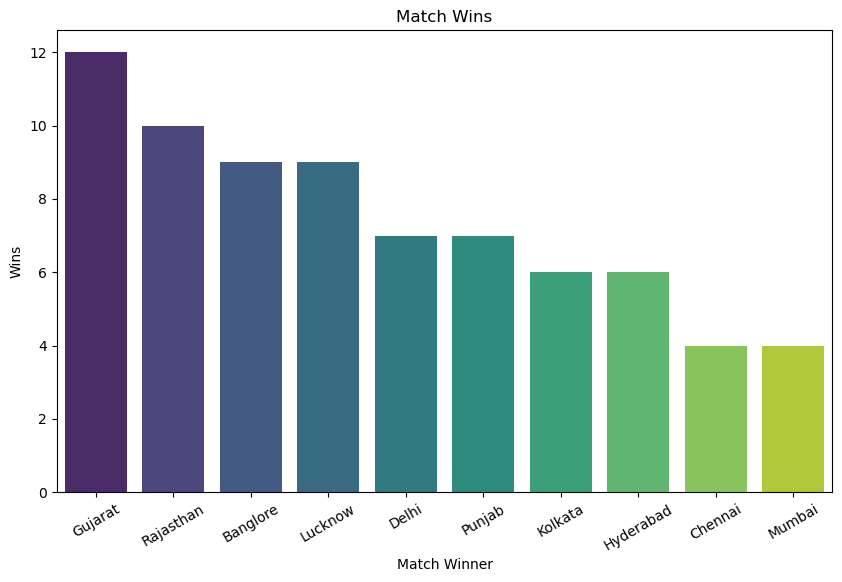

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(x=match_wins.index, y=match_wins.values, palette = 'viridis')

plt.xticks(rotation = 30)
plt.xlabel('Match Winner')
plt.ylabel('Wins')
plt.title('Match Wins')
plt.show()

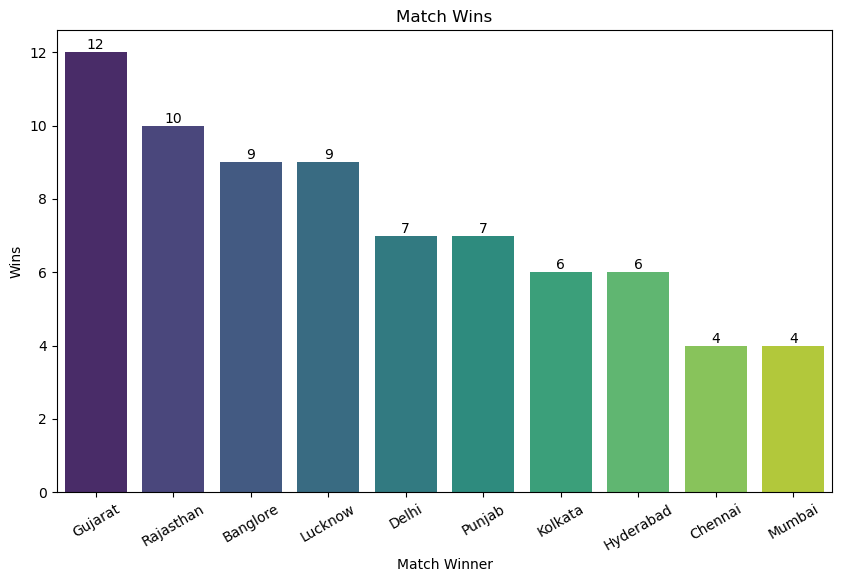

In [19]:
plt.figure(figsize=(10,6))

ax = sns.barplot(x=match_wins.index, y=match_wins.values, palette = 'viridis')

# Add data labels
for label in ax.containers:
    ax.bar_label(label)
    
plt.xticks(rotation = 30)
plt.xlabel('Match Winner')
plt.ylabel('Wins')
plt.title('Match Wins')
plt.show()

## `#2 .` Toss Decision Trends

In [20]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


Text(0.5, 1.0, 'Toss Decision')

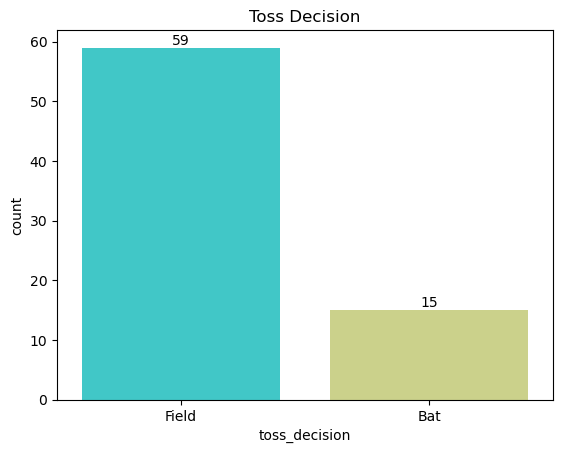

In [21]:
ax = sns.countplot(x = 'toss_decision', data = df, palette = 'rainbow')

for label in ax.containers:
    ax.bar_label(label)

plt.title('Toss Decision')


## `#3 .` Toss Winner VS Match Winner

In [22]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


In [23]:
toss_vs_winner_count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (toss_vs_winner_count *100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

## `#4 .` How do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Won By')

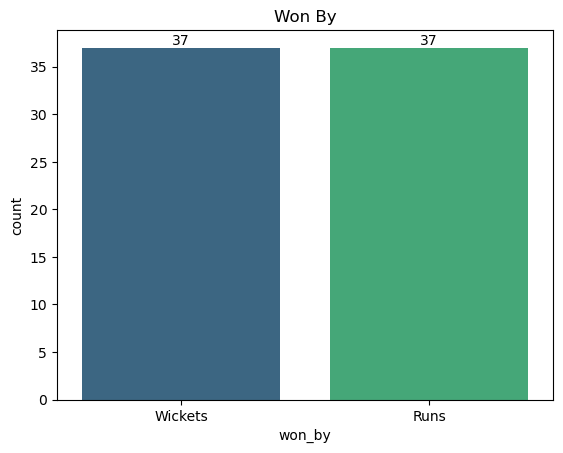

In [24]:
ax = sns.countplot(x =df['won_by'], palette = 'viridis')
for label in ax.containers:
    ax.bar_label(label)

plt.title("Won By")

# `# .` Key Player Performance

In [ ]:
df.head(3)

## `#1 .` Most 'player of the match' Awards

TypeError: 'str' object is not callable

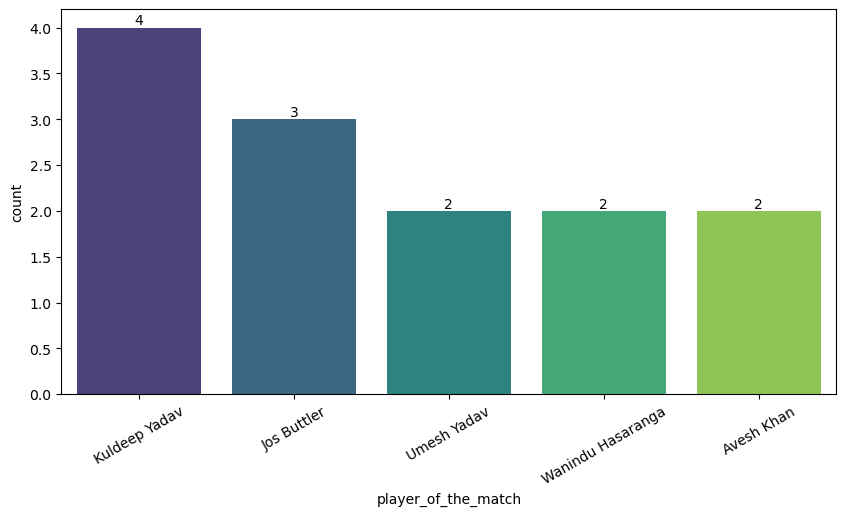

In [49]:
top5 = df['player_of_the_match'].value_counts().head(5)

plt.figure(figsize = (10,5))
ax = sns.countplot(x = df['player_of_the_match'], order = top5.index, palette = 'viridis')

for label in ax.containers:
    ax.bar_label(label)
    
plt.xticks(rotation = 30)
plt.xlabel('Player of the match')



# **OR**

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Kuldeep Yadav'),
  Text(1, 0, 'Jos Buttler'),
  Text(2, 0, 'Umesh Yadav'),
  Text(3, 0, 'Wanindu Hasaranga'),
  Text(4, 0, 'Avesh Khan')])

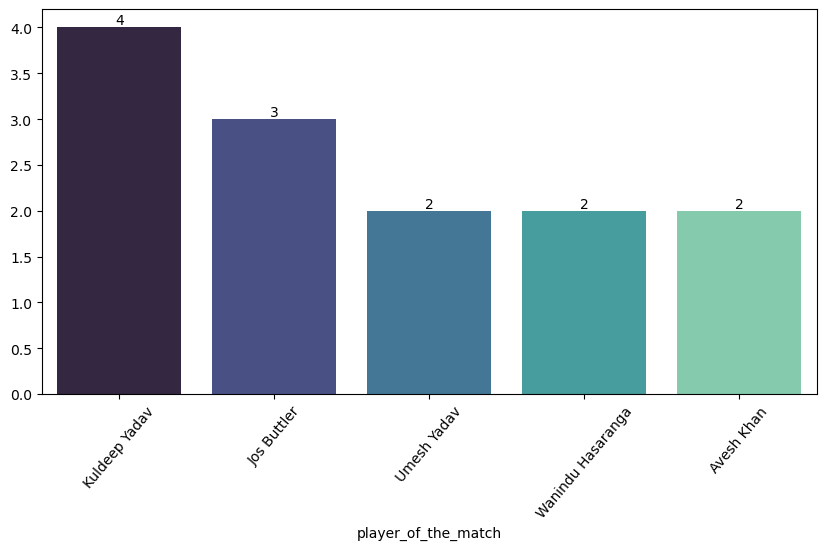

In [26]:
top5 = df['player_of_the_match'].value_counts().head(5)

plt.figure(figsize = (10,5))
ax =sns.barplot(x = top5.index, y = top5.values, palette = 'mako')

for label in ax.containers:
    ax.bar_label(label)
    
plt.xlabel = 'player of the match'
plt.ylabel = 'Count'
plt.xticks (rotation = 50)

<hr>

# **Function to add Data Label**

<hr>

In [29]:
def add_data_lable():
    for label in ax.containers:
        ax.bar_label(label)

if __name__ == "__main__":
    add_data_lable()

## `#2 .` Two Top Scorer

In [30]:
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59


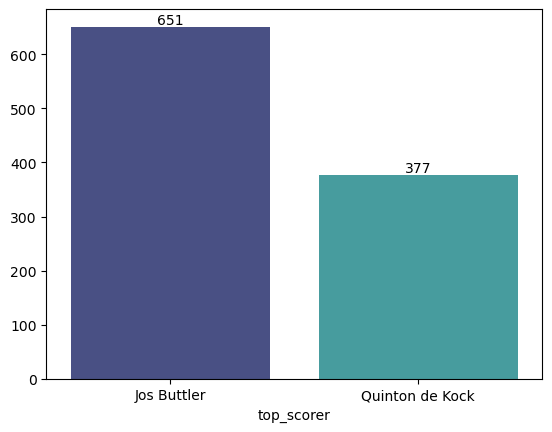

In [31]:
top_2_scorer = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)
top_2_scorer

ax = sns.barplot(x = top_2_scorer.index, y = top_2_scorer.values, palette = 'mako')

add_data_lable()

# **OR**

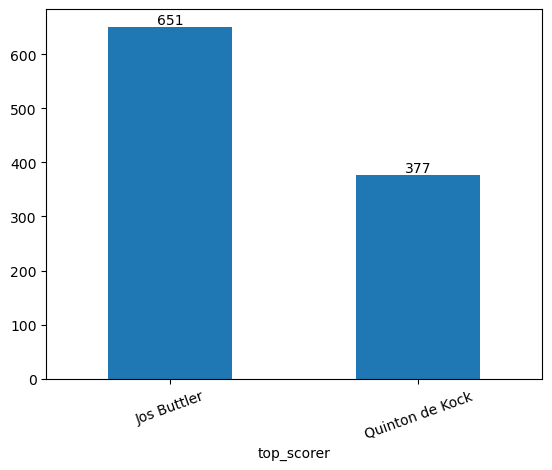

In [32]:
ax = top_2_scorer.plot(kind='bar')
plt.xticks(rotation = 20)

add_data_lable()

## `#3 .` 10 Best Bolling Figure

In [33]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


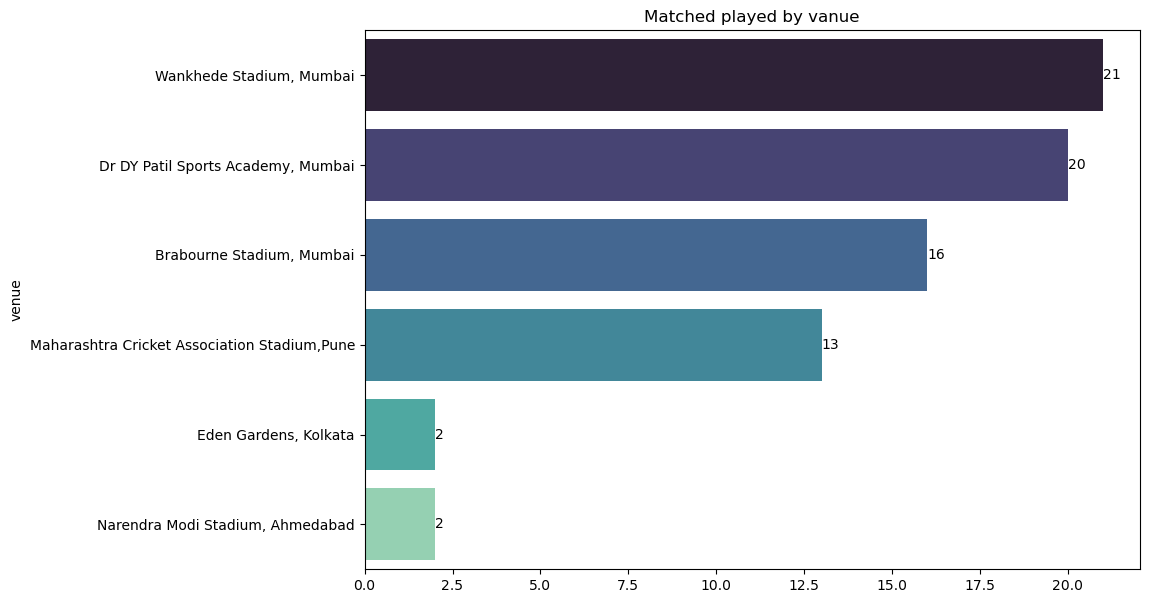

In [36]:
venue_count = df['venue'].value_counts()
plt.figure(figsize = (10,7))

ax = sns.barplot(y = venue_count.index, x = venue_count.values, palette = 'mako')

plt.title('Matched played by vanue')
add_data_lable()



In [37]:
df['top_wickets'] = df['best_bowling_figure'].apply(lambda x:x.split('--')[0])

df['top_wickets'] = df['top_wickets'].astype(int)
top_bolling_fig = df.groupby('best_bowling')['top_wickets'].sum().sort_values(ascending = False).head(10)
top_bolling_fig


best_bowling
Yuzvendra Chahal     17
Jasprit Bumrah       11
Kuldeep Yadav        11
Rashid Khan          11
Josh Hazlewood       10
Kagiso Rabada        10
Avesh Khan           10
Umran Malik           9
Wanindu Hasaranga     9
T Natarajan           8
Name: top_wickets, dtype: int64

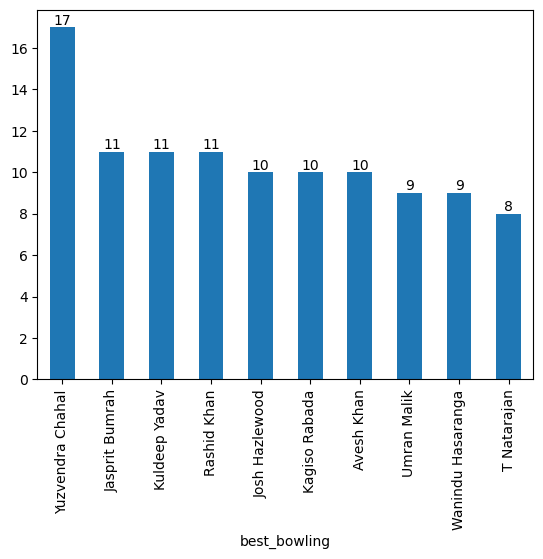

In [40]:
ax = top_bolling_fig.plot(kind='bar')
add_data_lable()

# `# .` **Vanue Analysis**

## `#3 .` Most matched played by vanue

In [41]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

# Custome Questions & Insights

###  Q1: Who won the highest margin by runs ?

In [42]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,top_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [43]:
df[df['won_by'] == 'Runs'].sort_values('margin', ascending = False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


###  Q2: Which player had the highest individual score?.

In [44]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


###  Q2: Which bowler had the nest bolling figures?.

In [45]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,top_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3


In [46]:
df[df['top_wickets'] == df['top_wickets'].max()][['best_bowling','top_wickets','best_bowling_figure']]

,best_bowling,top_wickets,best_bowling_figure
29,Yuzvendra Chahal,5,5--40
39,Umran Malik,5,5--25
53,Wanindu Hasaranga,5,5--18
55,Jasprit Bumrah,5,5--10
